# Github Project 1

## EDA

In [357]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [358]:
df = pd.read_csv(r'..\data\booking_reviews copy.csv')

In [359]:
df.head()

,index,review_title,reviewed_at,reviewed_by,images,crawled_at,url,hotel_name,hotel_url,avg_rating,nationality,rating,review_text,raw_review_text,tags,meta
0,0,Exceptional,11 July 2021,Kyrylo,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...","<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b..."
1,1,I highly recommend this b&b! We enjoyed it a lot!,24 November 2019,Dimitri,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,"<p class=""review_pos ""><svg aria-label=""Positi...",Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,"{'language': 'en-gb', 'source': 'https://www.b..."
2,2,Exceptional,3 January 2020,Virginia,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/hydro...,Hydro Palace Apartment,https://www.booking.com/hotel/be/hydro-palace....,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,"<p class=""review_neg ""><svg aria-label=""Negati...",Leisure trip~Couple~Apartment with Sea View~St...,"{'language': 'en-gb', 'source': 'https://www.b..."
3,3,My stay in the house was a experiencing bliss ...,8 September 2019,Kannan,NaN,"07/20/2021, 01:09:28",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,"<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b..."
4,4,One bedroom apartment with wonderful view and ...,23 June 2019,Sue,https://cf.bstatic.com/xdata/images/xphoto/squ...,"07/20/2021, 01:09:28",https://www.booking.com/reviews/be/hotel/hydro...,Hydro Palace Apartment,https://www.booking.com/hotel/be/hydro-palace....,9.2,South Africa,9.2,The building itself has a very musty smell in ...,"<p class=""review_neg ""><svg aria-label=""Negati...",Leisure trip~People with friends~Apartment wit...,"{'language': 'en-gb', 'source': 'https://www.b..."


In [360]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26675 entries, 0 to 26674
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            26675 non-null  int64  
 1   review_title     26674 non-null  str    
 2   reviewed_at      26570 non-null  str    
 3   reviewed_by      26570 non-null  str    
 4   images           938 non-null    str    
 5   crawled_at       26386 non-null  str    
 6   url              26386 non-null  str    
 7   hotel_name       26386 non-null  str    
 8   hotel_url        26386 non-null  str    
 9   avg_rating       26386 non-null  float64
 10  nationality      26370 non-null  str    
 11  rating           26386 non-null  float64
 12  review_text      26386 non-null  str    
 13  raw_review_text  26202 non-null  str    
 14  tags             26202 non-null  str    
 15  meta             26202 non-null  str    
dtypes: float64(2), int64(1), str(13)
memory usage: 3.3 MB


In [361]:
df.shape

(26675, 16)

In [362]:
df["language"] = df["meta"].str.extract(r"'language':\s*'([^']+)'")

In [363]:
columns_to_drop = ['index','reviewed_by','images','crawled_at','url','hotel_url','raw_review_text','meta']
df = df.drop(columns_to_drop, axis=1)
df.head()

,review_title,reviewed_at,hotel_name,avg_rating,nationality,rating,review_text,tags,language
0,Exceptional,11 July 2021,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",Business trip~Solo traveller~Junior Suite~Stay...,en-gb
1,I highly recommend this b&b! We enjoyed it a lot!,24 November 2019,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,en-gb
2,Exceptional,3 January 2020,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,Leisure trip~Couple~Apartment with Sea View~St...,en-gb
3,My stay in the house was a experiencing bliss ...,8 September 2019,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,Business trip~Solo traveller~Junior Suite~Stay...,en-gb
4,One bedroom apartment with wonderful view and ...,23 June 2019,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,Leisure trip~People with friends~Apartment wit...,en-gb


In [364]:
df.shape

(26675, 9)

In [365]:
df.isnull().sum()

review_title      1
reviewed_at     105
hotel_name      289
avg_rating      289
nationality     305
rating          289
review_text     289
tags            473
language        473
dtype: int64

In [366]:
df = df.dropna()
df.shape

(26185, 9)

In [367]:
df.isnull().sum()

review_title    0
reviewed_at     0
hotel_name      0
avg_rating      0
nationality     0
rating          0
review_text     0
tags            0
language        0
dtype: int64

In [368]:
df.head()

,review_title,reviewed_at,hotel_name,avg_rating,nationality,rating,review_text,tags,language
0,Exceptional,11 July 2021,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",Business trip~Solo traveller~Junior Suite~Stay...,en-gb
1,I highly recommend this b&b! We enjoyed it a lot!,24 November 2019,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,en-gb
2,Exceptional,3 January 2020,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,Leisure trip~Couple~Apartment with Sea View~St...,en-gb
3,My stay in the house was a experiencing bliss ...,8 September 2019,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,Business trip~Solo traveller~Junior Suite~Stay...,en-gb
4,One bedroom apartment with wonderful view and ...,23 June 2019,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,Leisure trip~People with friends~Apartment wit...,en-gb


In [369]:
df.info()


<class 'pandas.DataFrame'>
Index: 26185 entries, 0 to 26674
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   review_title  26185 non-null  str    
 1   reviewed_at   26185 non-null  str    
 2   hotel_name    26185 non-null  str    
 3   avg_rating    26185 non-null  float64
 4   nationality   26185 non-null  str    
 5   rating        26185 non-null  float64
 6   review_text   26185 non-null  str    
 7   tags          26185 non-null  str    
 8   language      26185 non-null  str    
dtypes: float64(2), str(7)
memory usage: 2.0 MB


In [370]:
df['date'] = pd.to_datetime(df['reviewed_at'], format='%d %B %Y')

df['year'] = df['date'].dt.year.astype(str)
df['month'] = df['date'].dt.strftime('%B')

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['date'].dt.month.apply(get_season)

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

In [371]:
df.head()

,review_title,reviewed_at,hotel_name,avg_rating,nationality,rating,review_text,tags,language,date,year,month,season
0,Exceptional,11 July 2021,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",Business trip~Solo traveller~Junior Suite~Stay...,en-gb,2021-07-11,2021,July,Summer
1,I highly recommend this b&b! We enjoyed it a lot!,24 November 2019,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,en-gb,2019-11-24,2019,November,Autumn
2,Exceptional,3 January 2020,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,Leisure trip~Couple~Apartment with Sea View~St...,en-gb,2020-01-03,2020,January,Winter
3,My stay in the house was a experiencing bliss ...,8 September 2019,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,Business trip~Solo traveller~Junior Suite~Stay...,en-gb,2019-09-08,2019,September,Autumn
4,One bedroom apartment with wonderful view and ...,23 June 2019,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,Leisure trip~People with friends~Apartment wit...,en-gb,2019-06-23,2019,June,Summer


In [372]:
df = df.drop(['reviewed_at'],axis=1)

In [373]:
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,tags,language,date,year,month,season
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",Business trip~Solo traveller~Junior Suite~Stay...,en-gb,2021-07-11,2021,July,Summer
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,en-gb,2019-11-24,2019,November,Autumn
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,Leisure trip~Couple~Apartment with Sea View~St...,en-gb,2020-01-03,2020,January,Winter
3,My stay in the house was a experiencing bliss ...,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,Business trip~Solo traveller~Junior Suite~Stay...,en-gb,2019-09-08,2019,September,Autumn
4,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,Leisure trip~People with friends~Apartment wit...,en-gb,2019-06-23,2019,June,Summer


In [374]:
df.iloc[0,6]

'Business trip~Solo traveller~Junior Suite~Stayed 1 night~Submitted via mobile'

In [375]:
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,tags,language,date,year,month,season
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",Business trip~Solo traveller~Junior Suite~Stay...,en-gb,2021-07-11,2021,July,Summer
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,en-gb,2019-11-24,2019,November,Autumn
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,Leisure trip~Couple~Apartment with Sea View~St...,en-gb,2020-01-03,2020,January,Winter
3,My stay in the house was a experiencing bliss ...,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,Business trip~Solo traveller~Junior Suite~Stay...,en-gb,2019-09-08,2019,September,Autumn
4,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,Leisure trip~People with friends~Apartment wit...,en-gb,2019-06-23,2019,June,Summer


In [376]:
df.shape

(26185, 12)

In [377]:
df['tags'].to_list()

['Business trip~Solo traveller~Junior Suite~Stayed 1 night~Submitted via mobile',
 'Leisure trip~Couple~Deluxe Suite~Stayed 1 night~Submitted via mobile',
 'Leisure trip~Couple~Apartment with Sea View~Stayed 6 nights~Submitted via mobile',
 'Business trip~Solo traveller~Junior Suite~Stayed 4 nights~Submitted via mobile',
 'Leisure trip~People with friends~Apartment with Sea View~Stayed 4 nights~Submitted via mobile',
 'Business trip~Couple~Junior Suite~Stayed 1 night~Submitted via mobile',
 'Business trip~Couple~Deluxe Double Room with Bath~Stayed 1 night~Submitted via mobile',
 'Leisure trip~Family with young children~Four-Bedroom House~Stayed 7 nights~Submitted via mobile',
 'Leisure trip~Couple~Apartment with Sea View~Stayed 3 nights~Submitted via mobile',
 'Business trip~Group~Deluxe Suite~Stayed 1 night',
 'Leisure trip~Couple~Deluxe Double Room with Bath~Stayed 2 nights~Submitted via mobile',
 'Leisure trip~People with friends~Four-Bedroom House~Stayed 2 nights~Submitted via mobi

In [378]:
for tag in df['tags'].to_list():
    print(tag)

Business trip~Solo traveller~Junior Suite~Stayed 1 night~Submitted via mobile
Leisure trip~Couple~Deluxe Suite~Stayed 1 night~Submitted via mobile
Leisure trip~Couple~Apartment with Sea View~Stayed 6 nights~Submitted via mobile
Business trip~Solo traveller~Junior Suite~Stayed 4 nights~Submitted via mobile
Leisure trip~People with friends~Apartment with Sea View~Stayed 4 nights~Submitted via mobile
Business trip~Couple~Junior Suite~Stayed 1 night~Submitted via mobile
Business trip~Couple~Deluxe Double Room with Bath~Stayed 1 night~Submitted via mobile
Leisure trip~Family with young children~Four-Bedroom House~Stayed 7 nights~Submitted via mobile
Leisure trip~Couple~Apartment with Sea View~Stayed 3 nights~Submitted via mobile
Business trip~Group~Deluxe Suite~Stayed 1 night
Leisure trip~Couple~Deluxe Double Room with Bath~Stayed 2 nights~Submitted via mobile
Leisure trip~People with friends~Four-Bedroom House~Stayed 2 nights~Submitted via mobile
Leisure trip~People with friends~Suite~Stay

In [379]:
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,tags,language,date,year,month,season
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",Business trip~Solo traveller~Junior Suite~Stay...,en-gb,2021-07-11,2021,July,Summer
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,en-gb,2019-11-24,2019,November,Autumn
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,Leisure trip~Couple~Apartment with Sea View~St...,en-gb,2020-01-03,2020,January,Winter
3,My stay in the house was a experiencing bliss ...,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,Business trip~Solo traveller~Junior Suite~Stay...,en-gb,2019-09-08,2019,September,Autumn
4,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,Leisure trip~People with friends~Apartment wit...,en-gb,2019-06-23,2019,June,Summer


In [380]:
df['tags'].str.count('~').value_counts()

tags
4    16672
3     9331
2      129
5       53
Name: count, dtype: int64

In [381]:
columns_to_drop = ['language','date']
df = df.drop(columns_to_drop, axis=1)
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,tags,year,month,season
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",Business trip~Solo traveller~Junior Suite~Stay...,2021,July,Summer
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,2019,November,Autumn
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,Leisure trip~Couple~Apartment with Sea View~St...,2020,January,Winter
3,My stay in the house was a experiencing bliss ...,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,Business trip~Solo traveller~Junior Suite~Stay...,2019,September,Autumn
4,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,Leisure trip~People with friends~Apartment wit...,2019,June,Summer


In [382]:
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,tags,year,month,season
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",Business trip~Solo traveller~Junior Suite~Stay...,2021,July,Summer
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,2019,November,Autumn
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,Leisure trip~Couple~Apartment with Sea View~St...,2020,January,Winter
3,My stay in the house was a experiencing bliss ...,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,Business trip~Solo traveller~Junior Suite~Stay...,2019,September,Autumn
4,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,Leisure trip~People with friends~Apartment wit...,2019,June,Summer


In [383]:
rooms = []
for tag in df['tags'].to_list():
    rooms.append(tag.split('~')[2])

set(rooms)

{'2 Adjacent Rooms',
 '4 Bed Dorm',
 '6 bed mixed dorm',
 'Ambassador Suite',
 'Apartment',
 'Apartment (2 Adults)',
 'Apartment (4 Adults)',
 'Apartment (4-6 Adults)',
 'Apartment - Ground Floor',
 'Apartment - Second Floor',
 'Apartment - Split Level',
 'Apartment 1',
 'Apartment 2',
 'Apartment 3',
 'Apartment 4',
 'Apartment 5',
 'Apartment 6',
 'Apartment with Balcony',
 'Apartment with Double Bed',
 'Apartment with Garden View',
 'Apartment with Sea View',
 'Apartment with Shower',
 'Apartment with Terrace',
 'August Experience',
 'Basic Double Room',
 'Basic Room',
 'Basic Triple Room - Basement',
 'Bed in 10-Bed Mixed Dormitory Room',
 'Bed in 12-Bed Mixed Dormitory Room',
 'Bed in 16-Bed Mixed Dormitory Room',
 'Bed in 4 Bed Female Dorm',
 'Bed in 4 Bed Mixed Dorm',
 'Bed in 4 Bed Mixed Dorm Ensuite',
 'Bed in 4-Bed Female Dormitory Room',
 'Bed in 4-Bed Female Dormitory Room with Shower',
 'Bed in 4-Bed Male Dormitory Room',
 'Bed in 4-Bed Male Dormitory Room with Shower',
 '

In [384]:
word_freq = {}
for categ in rooms:
    for word in categ.split():
        if word.lower() not in word_freq:
            word_freq[word.lower()] = 1
        else:
            word_freq[word.lower()] += 1
dict(sorted(word_freq.items(), key=lambda x: x[1], reverse=True))


{'room': 19593,
 'double': 11114,
 'standard': 5555,
 'twin': 4891,
 'with': 3849,
 'or': 2896,
 'superior': 2302,
 'apartment': 2140,
 'deluxe': 1966,
 'single': 1597,
 'bed': 1437,
 'comfort': 1063,
 'queen': 1029,
 'view': 1011,
 'studio': 995,
 'suite': 978,
 'stayed': 860,
 'bathroom': 855,
 'king': 811,
 'in': 793,
 'budget': 742,
 'family': 737,
 'triple': 730,
 '1': 662,
 'one-bedroom': 656,
 'two-bedroom': 648,
 'adults)': 621,
 'private': 569,
 'dormitory': 479,
 'garden': 476,
 'night': 434,
 'nights': 426,
 'classic': 422,
 '(2': 415,
 'shower': 414,
 '-': 397,
 'bath': 352,
 'house': 348,
 'quadruple': 344,
 'balcony': 338,
 'executive': 338,
 'room,': 323,
 'dorm': 321,
 'female': 316,
 '2': 299,
 'new': 284,
 'style': 284,
 'shared': 279,
 'junior': 268,
 'three-bedroom': 257,
 'terrace': 255,
 'cozy': 250,
 'mixed': 249,
 'economy': 243,
 'guest': 231,
 'holiday': 228,
 'home': 228,
 '4': 206,
 'small': 201,
 '6': 198,
 'bunk': 186,
 'canal': 174,
 'and': 159,
 'large':

In [385]:
room_categories = {
    'dormitory': r'dorm|dormitory|bunk|capsule|bed in',
    'single': r'single',
    'double': r'double',
    'twin': r'twin',
    'triple': r'triple',
    'quadruple': r'quadruple',
    'suite': r'suite|junior suite|penthouse',
    'studio': r'studio',
    'apartment': r'apartment',
    'family_room': r'family room|family suite',
    'villa': r'villa',
    'bungalow': r'bungalow',
    'chalet': r'chalet',
    'cottage': r'cottage',
    'house': r'house|townhouse|holiday home',
    'tent': r'tent|glamping',
    'loft': r'loft',
}

def categorize_room(text):
    if pd.isna(text):
        return 'unknown'
    text_lower = text.lower()
    for category, pattern in room_categories.items():
        if re.search(pattern, text_lower):
            return category
    return 'other'

df['residence_type'] = df['tags'].apply(categorize_room)
df['residence_type'].value_counts()



residence_type
double         11426
other           3248
twin            2225
apartment       2084
single          1642
suite           1097
dormitory        874
studio           853
triple           712
house            691
family_room      566
quadruple        356
loft             172
chalet            69
cottage           58
tent              50
villa             35
bungalow          27
Name: count, dtype: int64

In [386]:
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,tags,year,month,season,residence_type
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",Business trip~Solo traveller~Junior Suite~Stay...,2021,July,Summer,suite
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,2019,November,Autumn,suite
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,Leisure trip~Couple~Apartment with Sea View~St...,2020,January,Winter,apartment
3,My stay in the house was a experiencing bliss ...,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,Business trip~Solo traveller~Junior Suite~Stay...,2019,September,Autumn,suite
4,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,Leisure trip~People with friends~Apartment wit...,2019,June,Summer,apartment


In [387]:
pattern_trip = re.compile(r'business trip|leisure trip', re.IGNORECASE)
pattern_stays = re.compile(r'stayed \d+ nights?', re.IGNORECASE)
pattern_traveller = re.compile(r'solo traveller|couple|family with young childern|people with friends|group|pet', re.IGNORECASE)
pattern_submitted = re.compile(r'submitted.*$', re.IGNORECASE)

def extract_tag(tag_text, pattern):
    match_trip = pattern.search(tag_text)
    if match_trip:
        return match_trip.group().lower()
    
extract_tag('Leisure trip~Solo traveller~Junior Suite~Stayed 80 nights~Submitted via mobile',pattern_submitted)

'submitted via mobile'

In [388]:
df['trip_type'] = df['tags'].apply(lambda x: extract_tag(x, pattern_trip))
df['stays_length'] = df['tags'].apply(lambda x: extract_tag(x, pattern_stays))
df['traveller_type'] = df['tags'].apply(lambda x: extract_tag(x, pattern_traveller))
df['review_submission_device'] = df['tags'].apply(lambda x: extract_tag(x, pattern_submitted))

In [389]:
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,tags,year,month,season,residence_type,trip_type,stays_length,traveller_type,review_submission_device
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",Business trip~Solo traveller~Junior Suite~Stay...,2021,July,Summer,suite,business trip,stayed 1 night,solo traveller,submitted via mobile
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,2019,November,Autumn,suite,leisure trip,stayed 1 night,couple,submitted via mobile
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,Leisure trip~Couple~Apartment with Sea View~St...,2020,January,Winter,apartment,leisure trip,stayed 6 nights,couple,submitted via mobile
3,My stay in the house was a experiencing bliss ...,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,Business trip~Solo traveller~Junior Suite~Stay...,2019,September,Autumn,suite,business trip,stayed 4 nights,solo traveller,submitted via mobile
4,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,Leisure trip~People with friends~Apartment wit...,2019,June,Summer,apartment,leisure trip,stayed 4 nights,people with friends,submitted via mobile


In [390]:
df.info()

<class 'pandas.DataFrame'>
Index: 26185 entries, 0 to 26674
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   review_title              26185 non-null  str     
 1   hotel_name                26185 non-null  str     
 2   avg_rating                26185 non-null  float64 
 3   nationality               26185 non-null  str     
 4   rating                    26185 non-null  float64 
 5   review_text               26185 non-null  str     
 6   tags                      26185 non-null  str     
 7   year                      26185 non-null  str     
 8   month                     26185 non-null  category
 9   season                    26185 non-null  str     
 10  residence_type            26185 non-null  str     
 11  trip_type                 25319 non-null  str     
 12  stays_length              26185 non-null  str     
 13  traveller_type            21187 non-null  str     
 14  review

In [391]:
df['trip_type'].value_counts(dropna=False)

trip_type
leisure trip     19772
business trip     5547
NaN                866
Name: count, dtype: int64

In [392]:
df['residence_type'].value_counts(dropna=False)

residence_type
double         11426
other           3248
twin            2225
apartment       2084
single          1642
suite           1097
dormitory        874
studio           853
triple           712
house            691
family_room      566
quadruple        356
loft             172
chalet            69
cottage           58
tent              50
villa             35
bungalow          27
Name: count, dtype: int64

In [393]:
df['stays_length'].value_counts(dropna=False)

stays_length
stayed 1 night      12568
stayed 2 nights      7419
stayed 3 nights      3561
stayed 4 nights      1483
stayed 5 nights       546
stayed 6 nights       218
stayed 7 nights       175
stayed 8 nights        58
stayed 9 nights        37
stayed 10 nights       29
stayed 12 nights       19
stayed 11 nights       17
stayed 14 nights       17
stayed 13 nights        8
stayed 26 nights        4
stayed 16 nights        4
stayed 20 nights        4
stayed 30 nights        3
stayed 15 nights        3
stayed 19 nights        2
stayed 21 nights        2
stayed 17 nights        2
stayed 28 nights        2
stayed 25 nights        1
stayed 22 nights        1
stayed 27 nights        1
stayed 18 nights        1
Name: count, dtype: int64

In [394]:
df['traveller_type'].value_counts(dropna=False)

traveller_type
couple                 9458
solo traveller         7200
NaN                    4998
group                  2905
people with friends    1495
pet                     129
Name: count, dtype: int64

In [395]:
df[df['traveller_type'].isna()]

,review_title,hotel_name,avg_rating,nationality,rating,review_text,tags,year,month,season,residence_type,trip_type,stays_length,traveller_type,review_submission_device
7,Very good,Gite Namaste,9.3,Netherlands,8.3,"Spacious, more than enough rooms, a lot of bat...",Leisure trip~Family with young children~Four-B...,2019,August,Summer,house,leisure trip,stayed 7 nights,NaN,submitted via mobile
14,Superb,Novotel Gent Centrum,8.4,Sweden,9.0,The breakfast should be better for that hotel ...,Business trip~Family with young children~Super...,2021,July,Summer,double,business trip,stayed 6 nights,NaN,NaN
18,Lovely break in a lovely area. Car absolutely ...,Gite Namaste,9.3,United Kingdom,10.0,"Nothing :-),\n\nLovely area, lovely house, lov...",Leisure trip~Family with young children~Four-B...,2018,August,Summer,house,leisure trip,stayed 7 nights,NaN,NaN
21,Great location!,Novotel Gent Centrum,8.4,Germany,8.0,"The rooms seemed a little dated. ,\n\nThe loca...",Leisure trip~Family with young children~Superi...,2021,June,Summer,double,leisure trip,stayed 1 night,NaN,submitted via mobile
25,Fabulous,Gite Namaste,9.3,Netherlands,8.8,There are no comments available for this review,Leisure trip~Family with young children~Four-B...,2018,August,Summer,house,leisure trip,stayed 2 nights,NaN,submitted via mobile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26637,Good,Glamping op het Zeugekot,8.6,Belgium,7.0,There was no WiFi available and not enough hea...,Leisure trip~Family with young children~Tent~S...,2020,November,Autumn,tent,leisure trip,stayed 4 nights,NaN,submitted via mobile
26643,Terrible,Smartflats City - Royal,7.6,Morocco,1.0,It went well we were able to contact quickly b...,Family with young children~Two-Bedroom Apartme...,2021,May,Spring,apartment,NaN,stayed 2 nights,NaN,submitted via mobile
26653,Very good,Hotel Euro Capital Brussels,7.7,Romania,8.3,"This is a seven floor hotel made of wood, the ...",Leisure trip~Family with young children~Double...,2019,July,Summer,double,leisure trip,stayed 1 night,NaN,submitted via mobile
26664,great deal!,Aparthotel Adagio Access Bruxelles Europe Apar...,8.7,Germany,10.0,There are no comments available for this review,Leisure trip~Family with young children~Studio...,2019,May,Spring,studio,leisure trip,stayed 1 night,NaN,NaN


In [396]:
df['review_submission_device'].value_counts(dropna=False)

review_submission_device
submitted via mobile    17386
NaN                      8799
Name: count, dtype: int64

In [397]:
def extract_nights(text):
    if pd.isna(text):
        return None
    match = re.search(r'\d+', text)
    return int(match.group()) if match else None

df['stay_length'] = df['stays_length'].apply(extract_nights)

In [398]:
df.isna().sum()

review_title                   0
hotel_name                     0
avg_rating                     0
nationality                    0
rating                         0
review_text                    0
tags                           0
year                           0
month                          0
season                         0
residence_type                 0
trip_type                    866
stays_length                   0
traveller_type              4998
review_submission_device    8799
stay_length                    0
dtype: int64

In [399]:
df = df.drop(['review_submission_device','stays_length','tags'],axis=1)

In [400]:
df.isna().sum()

review_title         0
hotel_name           0
avg_rating           0
nationality          0
rating               0
review_text          0
year                 0
month                0
season               0
residence_type       0
trip_type          866
traveller_type    4998
stay_length          0
dtype: int64

In [401]:
df.shape

(26185, 13)

In [402]:
len(df['hotel_name'].unique())

819

In [403]:
df['hotel_name'].value_counts()

hotel_name
Motel One Brussels                               837
Marivaux Hotel                                   448
Snuffel Hostel                                   396
Hostel Bruegel                                   373
NH Brussels EU Berlaymont                        358
                                                ... 
Vakantiehuisje De Vuurtoren                        2
The Pearl                                          2
Majestic Apartment With Breathtaking Sea View      2
Hotel Neuvice                                      1
White Princess-Yzzis                               1
Name: count, Length: 819, dtype: int64

In [404]:
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,year,month,season,residence_type,trip_type,traveller_type,stay_length
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",2021,July,Summer,suite,business trip,solo traveller,1
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,2019,November,Autumn,suite,leisure trip,couple,1
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,2020,January,Winter,apartment,leisure trip,couple,6
3,My stay in the house was a experiencing bliss ...,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,2019,September,Autumn,suite,business trip,solo traveller,4
4,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,2019,June,Summer,apartment,leisure trip,people with friends,4


In [405]:
df.isna().sum()

review_title         0
hotel_name           0
avg_rating           0
nationality          0
rating               0
review_text          0
year                 0
month                0
season               0
residence_type       0
trip_type          866
traveller_type    4998
stay_length          0
dtype: int64

In [406]:
df = df.dropna()

In [407]:
df.info()

<class 'pandas.DataFrame'>
Index: 20508 entries, 0 to 26674
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   review_title    20508 non-null  str     
 1   hotel_name      20508 non-null  str     
 2   avg_rating      20508 non-null  float64 
 3   nationality     20508 non-null  str     
 4   rating          20508 non-null  float64 
 5   review_text     20508 non-null  str     
 6   year            20508 non-null  str     
 7   month           20508 non-null  category
 8   season          20508 non-null  str     
 9   residence_type  20508 non-null  str     
 10  trip_type       20508 non-null  str     
 11  traveller_type  20508 non-null  str     
 12  stay_length     20508 non-null  int64   
dtypes: category(1), float64(2), int64(1), str(9)
memory usage: 2.1 MB


In [408]:
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,year,month,season,residence_type,trip_type,traveller_type,stay_length
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",2021,July,Summer,suite,business trip,solo traveller,1
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,2019,November,Autumn,suite,leisure trip,couple,1
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,2020,January,Winter,apartment,leisure trip,couple,6
3,My stay in the house was a experiencing bliss ...,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,2019,September,Autumn,suite,business trip,solo traveller,4
4,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,2019,June,Summer,apartment,leisure trip,people with friends,4


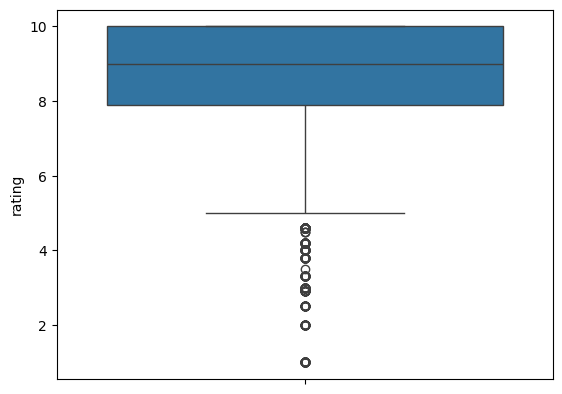

In [409]:
# create label
sns.boxplot(data=df, y='rating')
plt.show()

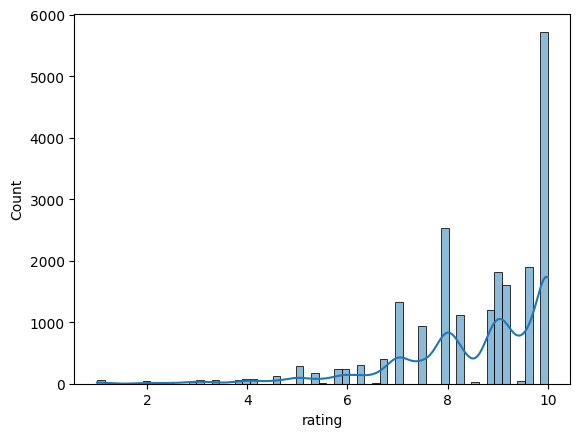

In [410]:
sns.histplot(data=df, x='rating', kde=True)
plt.show()

In [411]:
df['label'] = (df['rating'] > 7).astype(int)
df['label'].value_counts()

label
1    17494
0     3014
Name: count, dtype: int64

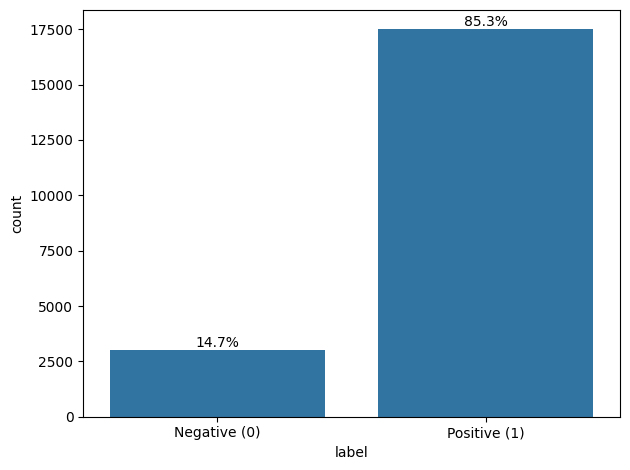

In [412]:
ax = sns.countplot(data=df, x='label')
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.xticks([0, 1], ['Negative (0)', 'Positive (1)'])
plt.tight_layout()
plt.show()

In [413]:
df[df['rating']<7]['review_text'].to_list()

['On the negative side: The bed was extremely soft and you roll together. The walls are thin, so I could hear other guests and their tv. However, we did book during May holidays so it was probably more expensive than usual.,\n\nOn the positive side: the location was very convenient, it is easy to access with a door code, and the owner was clear and communicative.',
 'Hotel advertises they have parking, only when I got to the hotel I was told I had to book and I have to park in public car park 5 minutes away and pay 22 euros per day. It was quiet upsetting when I looked at the booking email and found it at the very bottom of long email I had to pre-book in advance, booked this hotel because it said has parking :(. Also hotel says is 4 stars, sorry but that’s not true, fairly 3 stars. Room needs a refurbishment, clean corridors and lift.,\n\nCroissants was actually very nice, location very good.',
 'Despite having a fridge and microwave there were no plates or cutlery to use with the mic

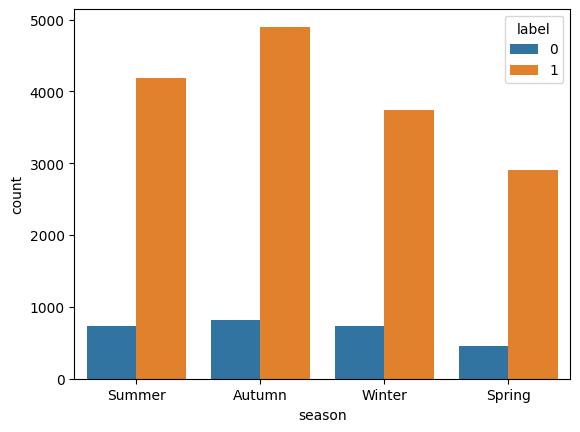

In [416]:
sns.countplot(data=df, x='season', hue='label')
plt.show()

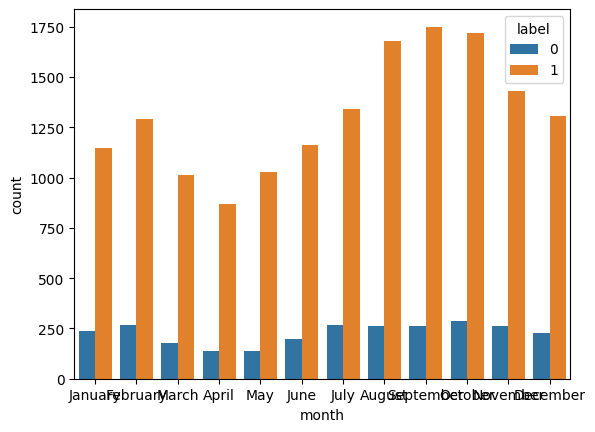

In [417]:
sns.countplot(data=df, x='month', hue='label')
plt.show()

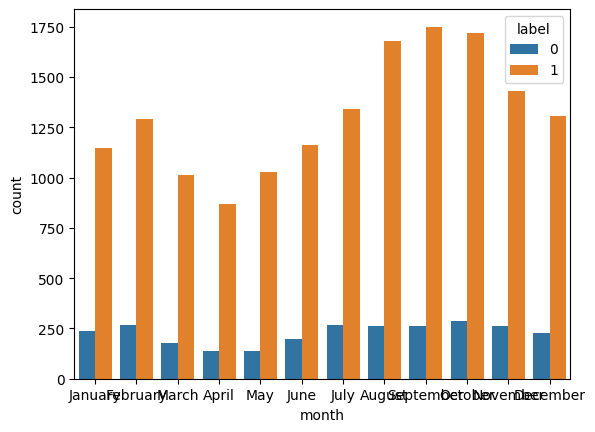

In [418]:
sns.countplot(data=df, x='month', hue='label')
plt.show()

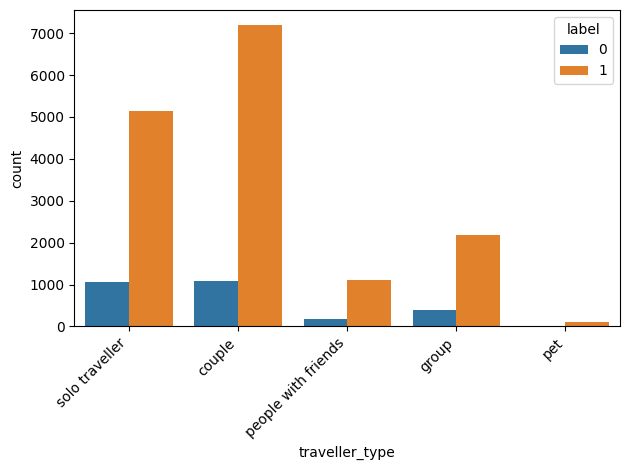

In [419]:
sns.countplot(data=df, x='traveller_type', hue='label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

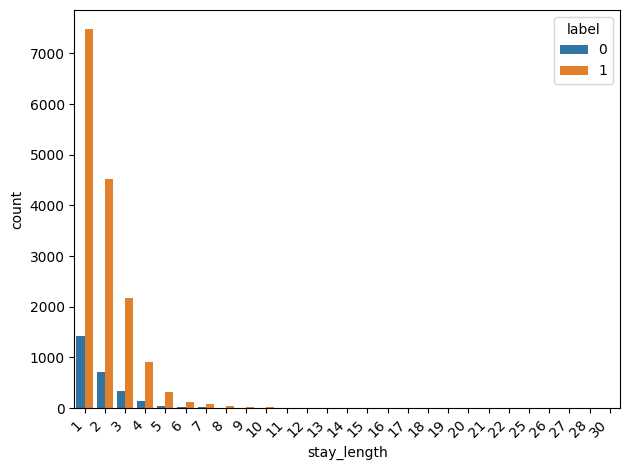

In [420]:
sns.countplot(data=df, x='stay_length', hue='label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [421]:
df.head()

,review_title,hotel_name,avg_rating,nationality,rating,review_text,year,month,season,residence_type,trip_type,traveller_type,stay_length,label
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",2021,July,Summer,suite,business trip,solo traveller,1,1
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,2019,November,Autumn,suite,leisure trip,couple,1,1
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,2020,January,Winter,apartment,leisure trip,couple,6,1
4,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,2019,June,Summer,apartment,leisure trip,people with friends,4,1
5,Fantastic! Beautiful home with a gracious welc...,Villa Pura Vida,9.7,United Kingdom,10.0,"Nothing,\n\nBeautiful home! Great room, most c...",2019,June,Summer,suite,business trip,couple,1,1


In [414]:
ground_truth = df.sample(frac=0.1, random_state=42)
df = df.drop(ground_truth.index)

ground_truth.to_csv(r'..\data\ground_truth.csv', index=False)

print(f"Ground truth size: {len(ground_truth)}")
print(f"Remaining dataset size: {len(df)}")

Ground truth size: 2051
Remaining dataset size: 18457


In [415]:
df.to_csv(r'..\data\booking_reviews_cleaned.csv', index=False)